In [1]:

import functools
import openai

def _default_retries(cls):
    original = cls.__init__

    @functools.wraps(original)
    def __init__(self, *args, **kwargs):
        kwargs.setdefault("max_retries", 12)
        original(self, *args, **kwargs)

    cls.__init__ = __init__

for _cls in (openai.OpenAI, openai.AsyncOpenAI):
    _default_retries(_cls)


You’ve dodged the internet’s ad barrage one too many times—pop-ups, banners, that 5-second YouTube teaser you’d trade anything to skip. How many ads hit you daily? How many feel like they get you, not some generic nobody? If you’re a brand, how often do your regulars see offers that truly spark their interest? Spoiler: not nearly enough.

Imagine ads that hook strangers in their native tongue and campaigns that captivate your loyal fans with perfect precision. Large language models like xAI’s Grok make this possible. Once, it was impractical for marketing teams to manually sift through user profiles and craft bespoke messages, too slow, too costly. Now, feed Grok the right context, and it takes over, blending nuanced language mastery with image-generation prowess to deliver hyper-personalized content across languages, formats, and tones in mere seconds.

## Table of Contents
- [Crafting Customers: Grok Builds Your Audience Profiles](#crafting-customers-grok-builds-your-audience-profiles)
  - [Synthetic Customer Generation](#synthetic-customer-generation)
  - [Persona Generation](#persona-generation)
- [Hyper Personalized Prompt](#hyper-personalized-prompt)
- [Image Generation](#image-generation)
  - [Meta-Prompting](#meta-prompting)
- [Final Results](#final-results)
- [Conclusion](#conclusion)

In [2]:
%pip install --quiet openai python-dotenv tqdm pandas aiofiles

Note: you may need to restart the kernel to use updated packages.


### Crafting Customers: Grok Builds Your Audience Profiles

Every campaign needs a target. For ads, it’s new users with basic traits. For marketing, it’s your known crowd, rich with history. Typically, you’d pull from your database, but here, we'll use Grok to create synthetic sample profiles from scratch. First, we'll use the structured outputs feature to create sample customers with attributes that would aid in generating targeted marketing/ad content. Second, we’ll task Grok with fleshing out vivid, concrete personas—written snapshots that bring these profiles to life, ready to inspire hyper-personalized campaigns.

#### Synthetic Customer Generation

Below, we define a Pydantic model to shape sample customers with attributes typical of an e-commerce setting. Then, we harness Grok’s [structured outputs](https://docs.x.ai/developers/model-capabilities/text/structured-outputs) feature to whip up 5 diverse profiles in one go.

In [3]:
import os

from dotenv import load_dotenv
from openai import AsyncOpenAI

load_dotenv()

TEXT_MODEL = "grok-4.7"
IMAGE_MODEL = "grok-imagine-image-2.0"

grok_client = AsyncOpenAI(
    base_url="https://api.x.ai/v1", api_key=os.getenv("XAI_API_KEY")
)

In [4]:
from enum import Enum

from pydantic import BaseModel


class Gender(Enum):
    MALE = "MALE"
    FEMALE = "FEMALE"


class Item(BaseModel):
    name: str
    category: str
    price: float
    purchase_date: str


class Customer(BaseModel):
    name: str
    age: int
    location: str
    gender: Gender
    language: str
    purchase_history: list[Item]
    interests: list[str]
    search_history: dict[str, str]
    preferred_device: str
    persona: str | None = None


class Customers(BaseModel):
    customers: list[Customer]

In [5]:
async def generate_customers(
    client: AsyncOpenAI, num_customers: int = 5, model: str = TEXT_MODEL
) -> Customers:
    prompt = f"""
    Generate {num_customers} sample customers with the following attributes:
    - age: int
    - location: str
    - gender: Gender
    - language: str
    - purchase_history: list[Item]
    - interests: list[str]
    - search_history: dict[str, str]
    - preferred_device: str

    Here are the attributes of an Item:
    - name: str
    - category: str
    - price: float
    - purchase_date: str

    Each customer generated should varied and distinct from the others: 
    - ensure a variety of languages are represented and not just english, however try to focus on commonly spoken languages instead of niche ones.
    - ensure the customers are from a variety of different countries and not just from one country
    - ensure the language attribute is set to the most commonly spoken language in that country
    - Have more english speaking customers than non-english speaking ones.

    Please set the persona attribute to null for all customers.
    """

    response = await client.responses.parse(
        model=model,
        input=prompt,
        text_format=Customers,
        temperature=1.2,
    )

    if not response.output_parsed:
        raise ValueError("No customers generated")

    return response.output_parsed

In [6]:
customers = await generate_customers(grok_client, num_customers=5, model=TEXT_MODEL)

In [7]:
for customer in customers.customers:
    print(customer.model_dump_json(indent=2))

{
  "name": "Sarah Mitchell",
  "age": 29,
  "location": "Austin, USA",
  "gender": "FEMALE",
  "language": "English",
  "purchase_history": [
    {
      "name": "Organic Cotton Yoga Mat",
      "category": "Fitness",
      "price": 48.99,
      "purchase_date": "2023-11-02"
    },
    {
      "name": "Pour-Over Coffee Kit",
      "category": "Kitchen",
      "price": 36.5,
      "purchase_date": "2024-02-18"
    }
  ],
  "interests": [
    "hiking",
    "specialty coffee",
    "live music"
  ],
  "search_history": {
    "weekend trails near Austin": "best hiking spots with shade",
    "home espresso setup": "compact grinders for small kitchens"
  },
  "preferred_device": "iPhone",
  "persona": null
}
{
  "name": "David Thompson",
  "age": 51,
  "location": "Manchester, United Kingdom",
  "gender": "MALE",
  "language": "English",
  "purchase_history": [
    {
      "name": "Noise-Cancelling Headphones",
      "category": "Electronics",
      "price": 229.0,
      "purchase_date": "20

#### Persona Generation

With our synthetic customers in hand, we can enrich them with detailed personas—textual summaries that make them feel real. Using the `AsyncOpenAI` client, we generate personas for all 5 customers concurrently.

In [8]:
from tqdm.asyncio import tqdm_asyncio


async def generate_persona(
    client: AsyncOpenAI, customer: Customer, model: str = TEXT_MODEL
) -> str:
    response = await client.responses.create(
        model=model,
        input=f"Generate a rich, 1-2 sentence persona for the following customer: {customer.model_dump_json(indent=2)}. The persona should suitable such that it can be used to generate a hyper-personalized ad or marketing piece.",
    )

    persona = response.output_text
    if not persona:
        raise ValueError("No persona generated")

    return persona


async def set_personas(
    client: AsyncOpenAI, customers: list[Customer]
) -> list[Customer]:
    coroutines = [generate_persona(client, customer) for customer in customers]
    personas = await tqdm_asyncio.gather(*coroutines, desc="Generating personas")

    for customer, persona in zip(customers, personas):
        customer.persona = persona

    return customers

In [9]:
updated_customers = await set_personas(grok_client, customers.customers)

Generating personas:   0%|          | 0/5 [00:00<?, ?it/s]

Generating personas:  20%|██        | 1/5 [00:26<01:45, 26.40s/it]

Generating personas:  40%|████      | 2/5 [00:41<00:58, 19.66s/it]

Generating personas:  60%|██████    | 3/5 [00:46<00:26, 13.25s/it]

Generating personas: 100%|██████████| 5/5 [00:52<00:00,  7.43s/it]

Generating personas: 100%|██████████| 5/5 [00:52<00:00, 10.58s/it]

In [10]:
for customer in updated_customers:
    print(customer.persona)

Sarah Mitchell is a 29-year-old Austin local who blends mindful movement and outdoor adventure—yoga on her organic mat and shaded weekend hikes—with a deep love of specialty coffee, from pour-overs to compact home espresso setups, all discovered and shopped on her iPhone between live-music nights.
David Thompson is a 51-year-old Manchester man who follows the Premier League closely—especially Manchester derby kickoff times—while restoring a Jaguar MK2 and listening to podcasts on his noise-cancelling headphones. He shops from a Windows laptop for practical quality, from a wool overcoat to railway history books and classic-car parts.
Emily Clarke is a 36-year-old Vancouver trail runner and sustainability advocate who gears up for rainy coastal paths with waterproof footwear and lightweight shells, shops reusable goods at downtown Saturday farmers’ markets, and edits her outdoor photography on a MacBook.
Hiroshi Tanaka, a 38-year-old Tokyo professional, unwinds with late-night Shinjuku r

### Hyper Personalized Prompt

With customers and personas ready, it’s time to craft hyper-personalized marketing messages. The prompt below instructs Grok to generate short, punchy ads tailored to each customer’s unique profile, think 50-100 words that pop with excitement, weave in at least three specific attributes (like age, interests, or purchase history), and match their language and local vernacular. These messages pitch a fresh product tied to their data, complete with a compelling hook and a clear call-to-action.

The prompt below includes a number of techniques that help get the best out of Grok these include:
- Role assignment
- A well defined task with specific criteria
- Detailed step by step instructions on how to perform the task
- Constraints to tell Grok what to avoid
- A reminder towards of the end of the prompt of the most important high-level instructions

In [11]:
async def generate_marketing_piece(
    client: AsyncOpenAI, customer: Customer, model: str = TEXT_MODEL
) -> str:
    prompt = f"""
    You are an expert marketing content generator tasked with creating hyper-personalized, engaging, and exciting advertising content for individual customers. Your goal is to leverage detailed customer data to craft tailored messages that resonate with their demographics, behaviors, and preferences, while optionally aligning with a brand style guide where possible.

    Below is the Customer schema outlining the attributes that will be provided as input:
    {Customer.model_json_schema()}

    Task
    Given a single `Customer` instance (provided as input), generate a short, personalized marketing message (50-100 words) that:
    1. Feels exciting, urgent, or exclusive to grab attention.
    2. Incorporates at least 3 specific attributes from the customer's data (e.g., `age`, `purchase_history`, `interests`).
    3. Matches the customer's `language` and uses idiomatic lingo based on the customer's `location`.
    4. Aligns with their `preferred_device` for delivery.
    5. Suggests a specific product or service (either dynamically generated or inferred from data) tied to their purchase history, interests, or search history - but not something they have recently purchased.

    Instructions
    1. Analyze the Customer: Use attributes like `age`, `gender`, `location`, `purchase_history`, `interests`, `search_history`, and `preferred_device` to understand the customer. If `persona` is missing, infer a simple persona (e.g., "Tech-Savvy Gamer," "Eco-Chic Shopper") based on patterns.
    2. Generate a Product/Service (if not provided): If no specific product is given, create one based on the customer’s data. Example: For a customer with `interests: ["sustainability"]` and `purchase_history: ["Dress"]`, suggest a "Vegan Leather Bag" in the "Fashion" category for $45.
    2. Personalized Greeting: Always address the customer by their first name in the greeting
    3. Tailor the Tone: Adjust language and style to suit `age`, `gender`, and `interests`. For younger audiences, use casual, vibrant tones; for older audiences, use polished, professional tones.
    4. Use the language of the customer: Use idiomatic vernacular based on the customer's `location`.
    5. Use emojis: Use emojis to add a bit more flair to the message, but don't overdo it.
    6. Leverage Context: Reference `location` (e.g., local events), `purchase_date` (e.g., time since last purchase), or `search_history` (e.g., intent) for relevance.
    7. Create Hooks: Use storytelling ("Remember your last buy?"), exclusivity ("For our top shoppers only"), or FOMO ("This week only!") to engage.
    8. Personalize Offers: Suggest the product with a compelling deal (e.g., discount, bundle) tied to `purchase_history` or `search_history`. Use plausible pricing if generating a product.
    9. Optimize Delivery: Format for `preferred_device`—short and visual for "mobile," detailed for "desktop."
    10. Stay Concise: Keep the message 50-100 words, punchy, and action-oriented with a clear call-to-action (CTA), using new lines for clarity and structure where necessary.

    Constraints
    - Do not invent customer data not present in the `Customer` instance.
    - Avoid generic phrases like "Dear Customer" unless no personalization data is available.
    - Use the exact `language` specified (e.g., English, Japanese) and match cultural nuances where possible.
    - Do not exceed 100 words unless explicitly requested.

    Remember to:
    - Be creative but grounded in the data.
    - If generating a product, ensure it’s plausible and tied to the customer’s profile.
    - If unsure about cultural references, keep it simple and data-driven.
    - Only output the final advertising content and nothing else.

    Here is the customer:
    {customer.model_dump_json(indent=2, exclude={"persona"})}

    Here is the customer persona:
    {customer.persona}

    Here is the target language:
    {customer.language}
    """
    response = await client.responses.create(
        model=model,
        input=prompt,
    )
    if not response.output_text:
        raise ValueError("No marketing piece generated")

    return response.output_text

In [12]:
marketing_pieces: list[str] = await tqdm_asyncio.gather(
    *[
        generate_marketing_piece(grok_client, customer)
        for customer in updated_customers
    ]
)

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:21<01:25, 21.47s/it]

 40%|████      | 2/5 [00:42<01:03, 21.01s/it]

 60%|██████    | 3/5 [00:49<00:29, 14.90s/it]

 80%|████████  | 4/5 [00:56<00:11, 11.47s/it]

100%|██████████| 5/5 [02:55<00:00, 50.53s/it]

100%|██████████| 5/5 [02:55<00:00, 35.16s/it]

In [13]:
import pandas as pd

pd.set_option("display.max_colwidth", None)


df = pd.DataFrame(
    {
        "Customer JSON": [
            customer.model_dump_json(indent=2) for customer in updated_customers
        ],
        "Customer Persona": [customer.persona for customer in updated_customers],
        "Marketing Piece": marketing_pieces,
    }
)

df

,Customer JSON,Customer Persona,Marketing Piece
0,"{\n ""name"": ""Sarah Mitchell"",\n ""age"": 29,\n ""location"": ""Austin, USA"",\n ""gender"": ""FEMALE"",\n ""language"": ""English"",\n ""purchase_history"": [\n {\n ""name"": ""Organic Cotton Yoga Mat"",\n ""category"": ""Fitness"",\n ""price"": 48.99,\n ""purchase_date"": ""2023-11-02""\n },\n {\n ""name"": ""Pour-Over Coffee Kit"",\n ""category"": ""Kitchen"",\n ""price"": 36.5,\n ""purchase_date"": ""2024-02-18""\n }\n ],\n ""interests"": [\n ""hiking"",\n ""specialty coffee"",\n ""live music""\n ],\n ""search_history"": {\n ""weekend trails near Austin"": ""best hiking spots with shade"",\n ""home espresso setup"": ""compact grinders for small kitchens""\n },\n ""preferred_device"": ""iPhone"",\n ""persona"": ""Sarah Mitchell is a 29-year-old Austin local who blends mindful movement and outdoor adventure—yoga on her organic mat and shaded weekend hikes—with a deep love of specialty coffee, from pour-overs to compact home espresso setups, all discovered and shopped on her iPhone between live-music nights.""\n}","Sarah Mitchell is a 29-year-old Austin local who blends mindful movement and outdoor adventure—yoga on her organic mat and shaded weekend hikes—with a deep love of specialty coffee, from pour-overs to compact home espresso setups, all discovered and shopped on her iPhone between live-music nights.","Hey Sarah! ☕\nAt 29, you're Austin's go-to for shaded hikes and specialty coffee vibes. Upgrade past your pour-over kit with our hot Compact Burr Grinder—perfect for those compact home espresso searches. iPhone exclusive: $50 flat this week only! Sync it with yoga flows or live music nights. Don't sleep—tap to buy now! 🥾🎶"
1,"{\n ""name"": ""David Thompson"",\n ""age"": 51,\n ""location"": ""Manchester, United Kingdom"",\n ""gender"": ""MALE"",\n ""language"": ""English"",\n ""purchase_history"": [\n {\n ""name"": ""Noise-Cancelling Headphones"",\n ""category"": ""Electronics"",\n ""price"": 229.0,\n ""purchase_date"": ""2023-08-14""\n },\n {\n ""name"": ""Wool Overcoat"",\n ""category"": ""Apparel"",\n ""price"": 185.75,\n ""purchase_date"": ""2024-01-09""\n },\n {\n ""name"": ""History of Railways"",\n ""category"": ""Books"",\n ""price"": 22.4,\n ""purchase_date"": ""2024-03-22""\n }\n ],\n ""interests"": [\n ""football"",\n ""classic cars"",\n ""podcasts""\n ],\n ""search_history"": {\n ""premier league fixtures"": ""Manchester derby kickoff time"",\n ""vintage car restoration"": ""suppliers for Jaguar MK2 parts""\n },\n ""preferred_device"": ""Windows laptop"",\n ""persona"": ""David Thompson is a 51-year-old Manchester man who follows the Premier League closely—especially Manchester derby kickoff times—while restoring a Jaguar MK2 and listening to podcasts on his noise-cancelling headphones. He shops from a Windows laptop for practical quality, from a wool overcoat to railway history books and classic-car parts.""\n}","David Thompson is a 51-year-old Manchester man who follows the Premier League closely—especially Manchester derby kickoff times—while restoring a Jaguar MK2 and listening to podcasts on his noise-cancelling headphones. He shops from a Windows laptop for practical quality, from a wool overcoat to railway history books and classic-car parts.","David, fancy sorting your Jaguar MK2 restoration proper? We've lined up an exclusive parts bundle just for Manchester enthusiasts like you! 🔧\n\nBased on your searches for MK2 suppliers, snag our Jaguar MK2 Genuine Restoration Kit – chrome bumpers, gaskets and all – for a cracking £165, this week only.\n\nPairs brilliantly with your podcasts and football chats. Head to our site on your Windows laptop and bag it before the derby kicks off! Act fast!"
2,"{\n ""name"": ""Emily Clarke"",\n ""age"": 36,\n ""location"": ""Vancouver, Canada"",\n ""gender"": ""FEMALE"",\n ""language"": ""English"",\n ""purchase_history"": [\n {\n ""name"": ""Waterproof Trail Runners"",\n ""category"": ""Footwear"",\n ""price"": 139.9

In just a couple of minutes we've created hyper personalized relevant marketing material, in a variety of vastly different languages, with idiomatic language. Our prompt above focuses on short punchy ads but this can easily be adjusted to fit a specific format or style to suit your needs.

### Image Generation

Why stop at text? Let’s amp up these marketing pieces with eye-catching images. Using Grok’s [image-generation capabilities](https://docs.x.ai/developers/model-capabilities/images/generation), we’ll create visuals based on each marketing message and persona. These images spotlight the product in a stylized, engaging scene—think vibrant watercolors or bold graphics tied to the customer’s interests and lifestyle, all without humans to keep the focus tight.

#### Meta-Prompting

Typically, the image generation API works by taking a prompt that describes the image you want created. We could pass a prompt directly here, but instead, we use a meta-prompt, a prompt fed into a non-image-generation model to craft a tailored prompt optimized for the image gen API. This lets us get ultra-specific, ensuring the generated prompt perfectly aligns with the customer’s persona and marketing piece for standout visuals.

In [14]:
async def generate_image_prompt(
    client: AsyncOpenAI,
    marketing_piece: str,
    customer_persona: str,
    model: str = TEXT_MODEL,
) -> str:
    meta_prompt = f"""
    Create a concise and detailed prompt optimized for an image generation model based on the persona and marketing piece provided below.

    The generated prompt should:
    - Instruct the model to create an image promoting the product or service from the marketing piece, with the product or service as the central focus.
    - Exclude humans from the image.
    - Place the product or service in a visually engaging, stylized context that reflects the persona’s interests, lifestyle, or preferences.  
    - Include subtle background elements or details that tie into the persona’s characteristics (e.g., hobbies, environment) to enhance relevance, without distracting from the product or service.  
    - Use vivid, descriptive language to inspire a creative and unique visual output, keeping the tone imaginative rather than literal.
    - Instruct the model to use different styles, not all photos need to be hyper-realistic but some may be more artistic, sketched, paintings, watercolor style etc. The style used should be chosen based on the marketing piece and persona.
    - Format the output as a single, flowing sentence or short paragraph, avoiding lists or numbered steps, suitable for direct input into an image generation tool.

    Steps to Generate the Prompt:
    1. Analyze the marketing piece to pinpoint the product or service and its key selling points.
    2. Examine the persona to extract specific traits, interests, or motivations that connect to the product or service.
    3. Craft a scene where the product or service shines in a context meaningful to the persona, such as the city or location, blending in subtle, complementary details based on the persona's characteristics. 
    4. Ensure the language is evocative, visual, and concise, tailored for an image generation model’s interpretation.

    Persona:
    {customer_persona}

    Marketing Piece:
    {marketing_piece}
    """

    response = await client.responses.create(
        model=model,
        input=meta_prompt,
    )

    if not response.output_text:
        raise ValueError("No image prompt generated")

    return response.output_text

In [15]:
import base64
import os
import uuid

import aiofiles


async def generate_image(
    client: AsyncOpenAI, marketing_piece: str, customer_persona: str, filepath: str
) -> str:
    image_prompt = await generate_image_prompt(
        client, marketing_piece, customer_persona
    )
    print(image_prompt)

    response = await client.images.generate(
        model=IMAGE_MODEL, prompt=image_prompt, response_format="b64_json"
    )
    if not response.data:
        raise ValueError("No image generated")

    b64_json = response.data[0].b64_json
    if b64_json is None:
        raise ValueError("No base64 data received in response")

    image_data = base64.b64decode(b64_json)
    filename = os.path.join(filepath, f"generated_image_{uuid.uuid4().hex[:5]}.jpg")
    async with aiofiles.open(filename, "wb") as f:
        await f.write(image_data)

    return filename

In [16]:
async def generate_all_images(client: AsyncOpenAI, df: pd.DataFrame, images_dir: str):
    tasks = [
        generate_image(
            client, row["Marketing Piece"], row["Customer Persona"], images_dir
        )
        for _, row in df.iterrows()
    ]

    image_paths = await tqdm_asyncio.gather(*tasks)

    df["image_path"] = image_paths
    return df

In [17]:
df = await generate_all_images(grok_client, df, "generated_images/")

  0%|          | 0/5 [00:00<?, ?it/s]

A sleek lightweight breathable cycling helmet glows as the luminous centerpiece in a vibrant anime-watercolor fusion illustration, resting atop a minimalist bicycle amid a dreamy neon-lit Shinjuku night where soft steam curls from distant ramen bowls, delicate ceramic motifs shimmer in the haze, and faint keyboard-like sparkles drift through the sophisticated urban glow, all without any human presence.


An elegant still-life watercolor of the Kit Arte & Sapori as luminous centerpiece, its refined terracotta-and-gold box open to reveal handwritten cream-free carbonara recipe cards and gleaming gallery tickets, nestled amid soft washes of Roman ruins, marble museum arches, and a rustic plate of golden pasta with pecorino and guanciale, all rendered in fluid artistic strokes of warm ochre, sage, and ivory that whisper stylish Roman gallery weekends and authentic flavors.


 20%|██        | 1/5 [00:22<01:31, 22.78s/it]

 40%|████      | 2/5 [00:34<00:48, 16.31s/it]

...

A soft ethereal watercolor painting centered on sleek waterproof trail runners paired with a lightweight rain shell of recycled materials, artfully draped over a moss-covered log on a misty Vancouver coastal trail where rain-kissed ferns and towering evergreens frame distant ocean waves, with subtle nearby details of a reusable farmers’-market tote and a closed MacBook showing faint trail photos nestled in the undergrowth, all rendered in an imaginative painterly style without any people.


A richly textured oil painting captures the Jaguar MK2 Genuine Restoration Kit as the gleaming centerpiece, its polished chrome bumpers and precise gaskets arranged with elegant precision on a weathered oak workbench inside a moody Manchester workshop, bathed in warm amber light that accentuates every metallic curve and seal, while subtle background whispers of a folded wool overcoat, resting noise-cancelling headphones, an open railway history volume, and a softly shadowed Premier League scarf evoke quiet passion without any human presence.


 80%|████████  | 4/5 [01:09<00:16, 16.66s/it]

100%|██████████| 5/5 [01:15<00:00, 12.66s/it]

100%|██████████| 5/5 [01:15<00:00, 15.04s/it]

### Final Results

Now that we’ve generated images and personas, let’s take a look at how these hyper-personalized marketing pieces come together with their custom visuals to captivate each customer.

Hey Sarah! ☕
At 29, you're Austin's go-to for shaded hikes and specialty coffee vibes. Upgrade past your pour-over kit with our hot Compact Burr Grinder—perfect for those compact home espresso searches. iPhone exclusive: $50 flat this week only! Sync it with yoga flows or live music nights. Don't sleep—tap to buy now! 🥾🎶



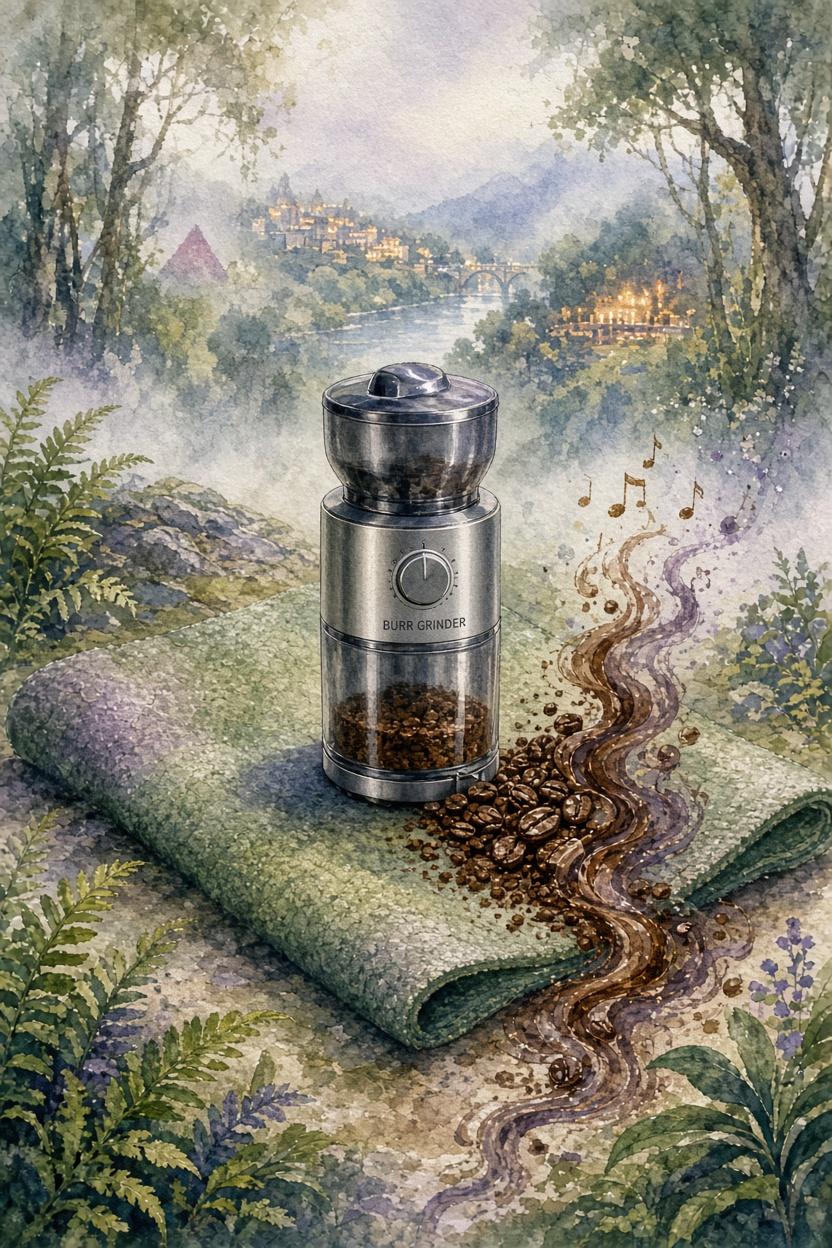


David, fancy sorting your Jaguar MK2 restoration proper? We've lined up an exclusive parts bundle just for Manchester enthusiasts like you! 🔧

Based on your searches for MK2 suppliers, snag our Jaguar MK2 Genuine Restoration Kit – chrome bumpers, gaskets and all – for a cracking £165, this week only.

Pairs brilliantly with your podcasts and football chats. Head to our site on your Windows laptop and bag it before the derby kicks off! Act fast!



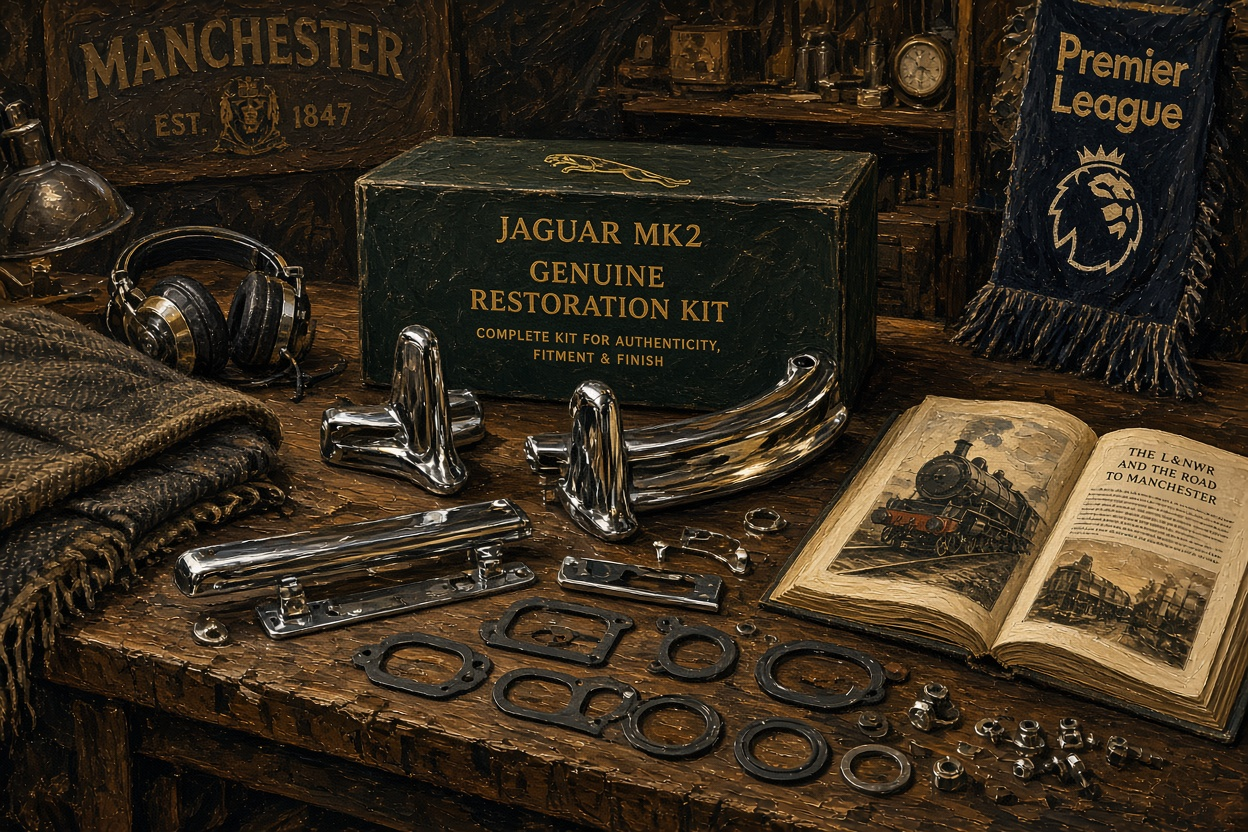


Emily, your Vancouver coastal trails are calling! 🌲

Remember those Waterproof Trail Runners? Pair them with our exclusive sustainable Lightweight Rain Shell—crafted from recycled materials, ideal for the rainy West Coast weather you've been eyeing.

Only $89 this weekend (usually $149) for eco-minded runners like you who love Saturday downtown farmers’ markets.

Capture stunning trail photography and edit it right on your MacBook.

Limited stock—claim yours now!



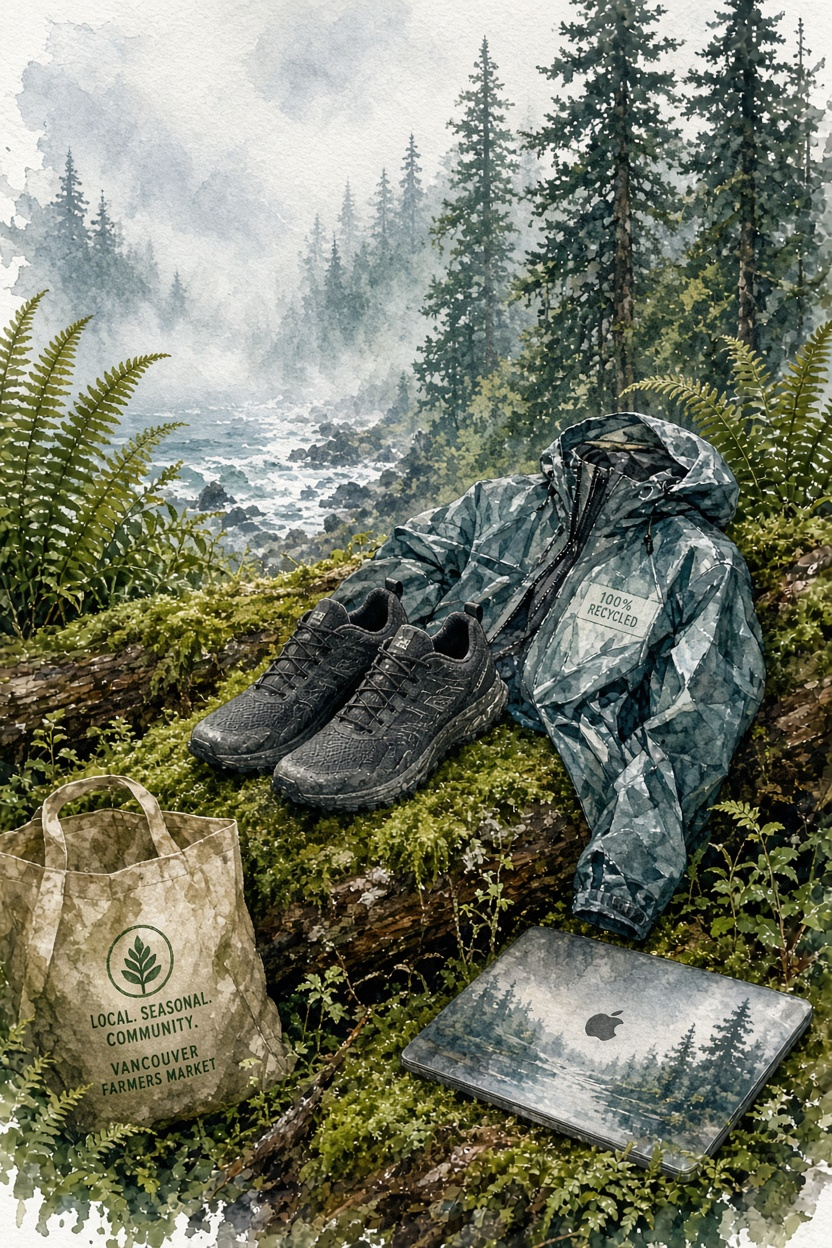


ヒロシさん！新宿の深夜ラーメンが待ちきれないあなたへ✨
38歳の東京通勤を変える軽量通気ヘルメット「ブリーズマックス」。検索どおりのモデルで今週だけ9,900円！アーバンサイクリングが加速し、セラミックの器みたいに洗練された毎日に。Androidですぐタップ、限定は間もなく終了！🚴‍♂️🍜



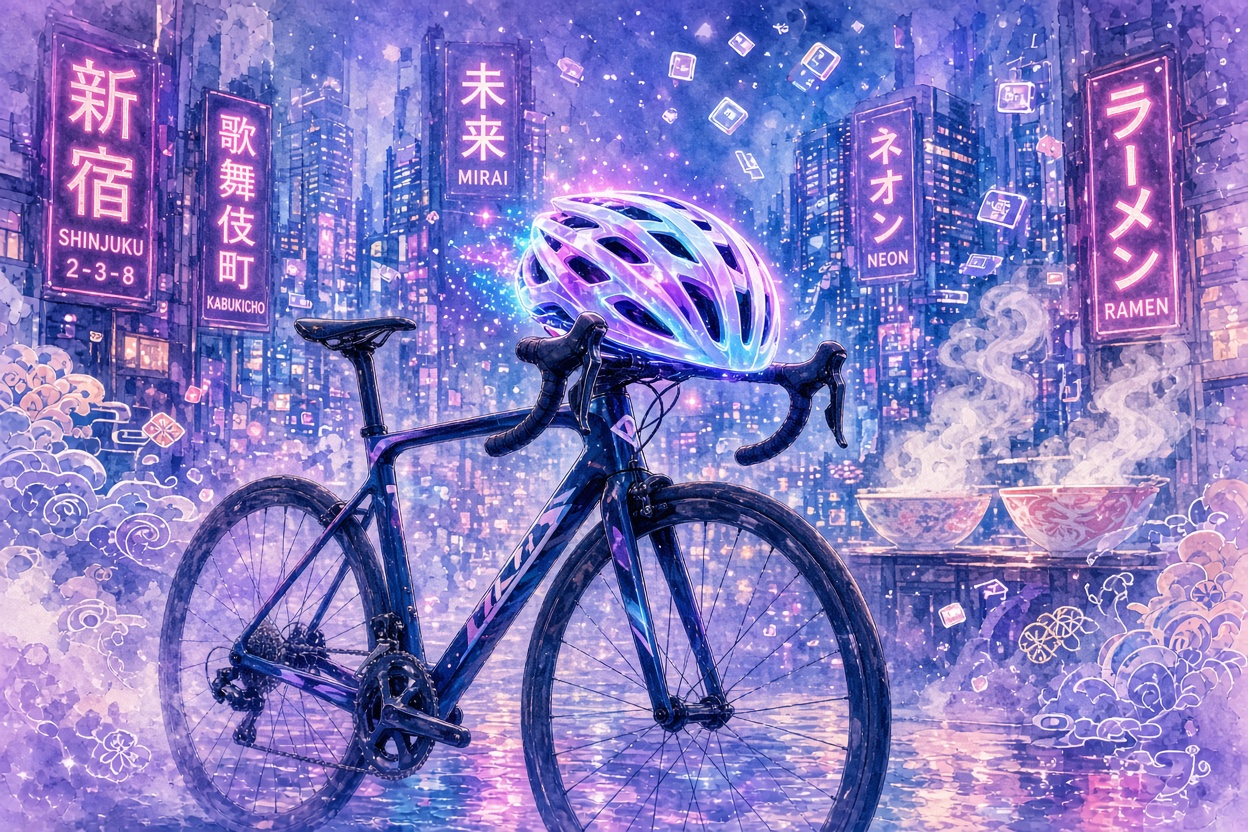


Ciao Sofia! 😍
Da vera romana amante dei musei e della carbonara senza panna, non puoi perdere questa esclusiva: il Kit Arte & Sapori, con ricette tradizionali e biglietti per le gallerie di questo weekend.
Ispirato ai tuoi acquisti eleganti, solo 38€ con 20% di sconto sul tuo iPad – offerta lampo fino a domenica!
Daje, clicca ora e viaggia nei sapori di Roma! 🍝🖼️



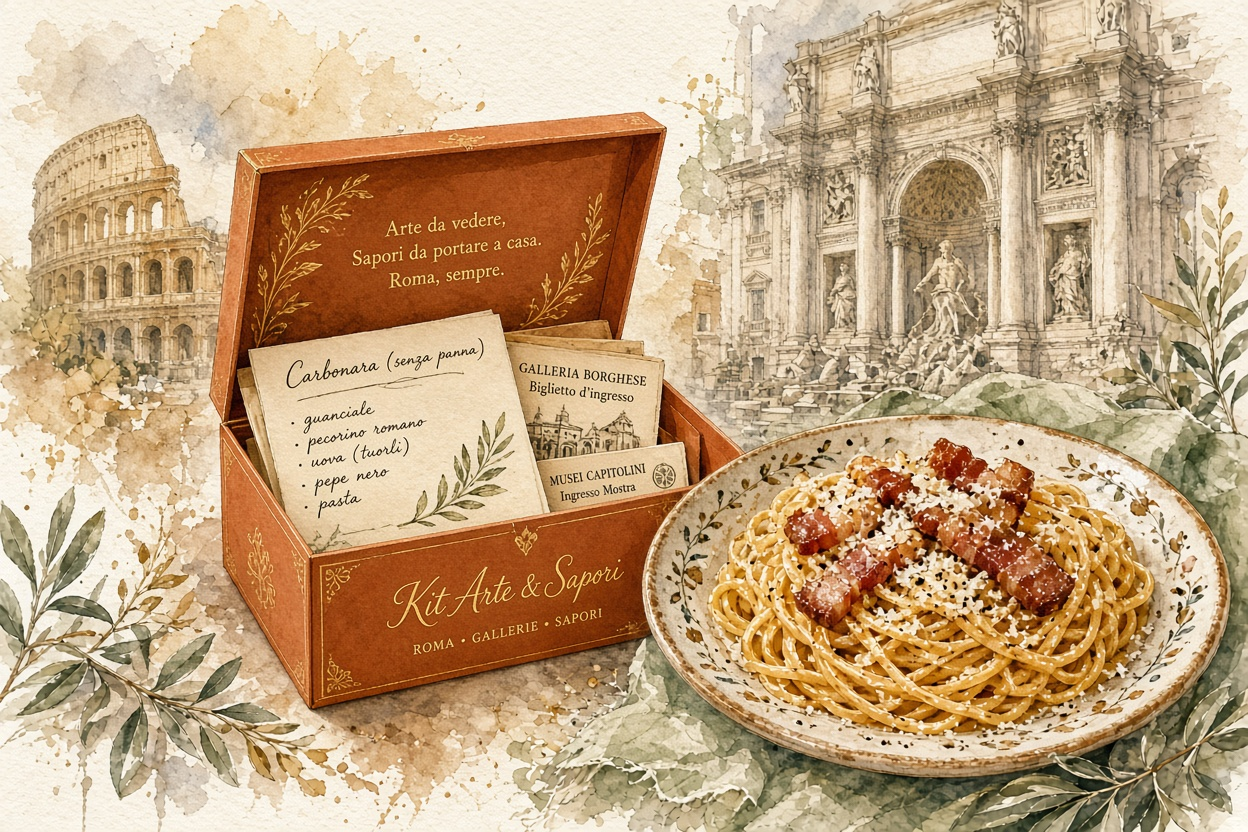

In [18]:
from IPython.display import Image

for index, row in df.iterrows():
    print(f"{row['Marketing Piece']}\n")
    display(Image(row["image_path"], width=600))
    print()

Pretty cool!

## Conclusion

Starting with nothing, we’ve built a powerful pipeline that runs in the order of minutes to deliver hyper-personalized marketing messages along with custom images for each user. Let's quickly recap some of what we covered:

- Synthetic Data Generation using Structured Outputs
- Using prompt engineering best practices to generate hyper personalized marketing messages
- Using meta prompting to generate prompts optimized for image generation

We only scratched the surface, here are some ideas for you to try to take this even further:
- Update the text generation prompt to incorporate your organization's brand voice/style guide
- Update the text generation prompt so that it can adhere to a specific template for the generated message.

